# Load stellar mass distribution for various populations

**UPDATE**</br>
We have precomputed distributions for various $\rm \chi_{SFR}$ values in the range [0,1], with resolution $\rm \Delta \chi_{SFR} = 0.01$.  


In [2]:
# Libraries
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
import os, re
#plt.style.use("nick_style")


**Load the simulated populations**

In [21]:
out_dir = 'p_mass_dists/' # Directory where the file is located. Change accordingly
Delta_chi = 0.01 # Step size for chi values (this is the resolution of the chi grid)
chi_vals = np.arange(0, 1 + Delta_chi, Delta_chi)

In [11]:
def get_sorted_chi_distr(out_dir):
    # List all files in the directory
    files = os.listdir(out_dir)
    
    # Filter files containing 'chi'
    chi_files = [f for f in files if 'chi_' in f]
    
    # Extract the number after 'chi' and sort files based on it
    def extract_number(file_name):
        match = re.search(r'chi_([0-9]*\.?[0-9]+)', file_name)
        return float(match.group(1)) if match else float('inf')  # Use 'inf' for files without a number
    
    sorted_files = sorted(chi_files, key=extract_number)
    return sorted_files

# Example usage
sorted_distr = get_sorted_chi_distr(out_dir)
print(sorted_distr)

['stellar_mass_distr_chi_0.00.h5', 'stellar_mass_distr_chi_0.01.h5', 'stellar_mass_distr_chi_0.02.h5', 'stellar_mass_distr_chi_0.03.h5', 'stellar_mass_distr_chi_0.04.h5', 'stellar_mass_distr_chi_0.05.h5', 'stellar_mass_distr_chi_0.06.h5', 'stellar_mass_distr_chi_0.07.h5', 'stellar_mass_distr_chi_0.08.h5', 'stellar_mass_distr_chi_0.09.h5', 'stellar_mass_distr_chi_0.10.h5', 'stellar_mass_distr_chi_0.11.h5', 'stellar_mass_distr_chi_0.12.h5', 'stellar_mass_distr_chi_0.13.h5', 'stellar_mass_distr_chi_0.14.h5', 'stellar_mass_distr_chi_0.15.h5', 'stellar_mass_distr_chi_0.16.h5', 'stellar_mass_distr_chi_0.17.h5', 'stellar_mass_distr_chi_0.18.h5', 'stellar_mass_distr_chi_0.19.h5', 'stellar_mass_distr_chi_0.20.h5', 'stellar_mass_distr_chi_0.21.h5', 'stellar_mass_distr_chi_0.22.h5', 'stellar_mass_distr_chi_0.23.h5', 'stellar_mass_distr_chi_0.24.h5', 'stellar_mass_distr_chi_0.25.h5', 'stellar_mass_distr_chi_0.26.h5', 'stellar_mass_distr_chi_0.27.h5', 'stellar_mass_distr_chi_0.28.h5', 'stellar_mass

In [14]:
# Load in data

def gather_mass_distr(out_dir, fnames):

    GRAND_MASS_DISTR_with_mcut = []
    GRAND_MASS_DISTR_raw = []
    for i, fname in enumerate(fnames):

        with h5py.File(out_dir + fname, 'r') as hf:
            cdfmass_with_mcut = hf['p_mass_distr_magcut'][:,:]
            cdfmass_mass_weighted_raw = hf['p_mass_distr_raw'][:,:]
            massedges = hf['mass_bin_edges'][:]
            zbins = hf['z_bins'][:]
        # Get the chi value from the filename
        GRAND_MASS_DISTR_with_mcut.append(cdfmass_with_mcut)
        GRAND_MASS_DISTR_raw.append(cdfmass_mass_weighted_raw)
    return np.array(GRAND_MASS_DISTR_with_mcut), np.array(GRAND_MASS_DISTR_raw), massedges, zbins


GRAND_MASS_DISTR_with_mcut, GRAND_MASS_DISTR_raw, massedges, zbins = gather_mass_distr(out_dir, sorted_distr)
        


In [15]:
GRAND_MASS_DISTR_raw.shape  # shape = (chi_values, z_values, mass_values)

(101, 3, 199)

The loaded datasets contains precomputed cumulative distribution functions in stellar mass for mixed populations with different $\rm chi_{SFR}$ values. $\rm chi_{SFR} = 1$ refers to a fully SFR-weighted population, whereas $\rm chi_{SFR}=0$ corresponds to the fully mass-weighted population. The details are described in Loudas et al. (2025). 

The `GRAND_MASS_DISTR_raw` and `GRAND_MASS_DISTR_with_mcut` contain all populations. The shape of these "GRAND" arrays is $\rm (i=N_\chi, ~j=N_z, ~k=N_{mass})$

Each population has two separate CDFs: one that describes the full population, denoted by the term 'raw', and one corresponding to the population that satisfies the optical-selection critetion $m_r <23.5$, denoted by 'mcut'.

Each mixed population has been computed before applying any magntitude cut, which is the only way for $\rm \chi_{SFR}$ to have a physical meaning and be biased-free.

For given population, i.e., for a given $\rm i = np.argmin(|chi_{SFR} - chi_{i})$, the CDF `GRAND_MASS_DISTR_with_mcut[i]` or `GRAND_MASS_DISTR_raw[i]` have three branches, i.e., three redshift bins ($\rm j = 0,1,2$). 

`GRAND_MASS_DISTR_raw[i, j, :]` -> CDF in stellar mass of the raw population

`GRAND_MASS_DISTR_with_mcut[i, j, :]` -> CDF in stellar mass of the magnitude-limited population

`massedges` -> logmass bin edges in which all CDFs are computed

`zbins` -> redshift bins of each population: [0,0.2,0.4, 0.7]

Structure of `CDF arrays` = `[len(zbins) - 1, len(massedges) - 1]`

**How to build a mixed population** (You can skip all the detailed mentioned above and just use the model as describd here)

It's already precomputed! </br>
Call the function </br>
`cdfmass_mixed_population_with_mcut(zbins_index, chi)` (or `cdfmass_mixed_population_raw(zbins_index, chi)` </br>
depending on what population is more relevant for your study) using the $\rm \chi_{SFR}$ value of your interest. As a reminder, $\chi_{SFR}$ refers to the percentage of FRBs that trace SFR as opposed to the mass tracers. $\chi_{SFR} = 0$ implies all FRBs are mass tracers, whereas $\chi_{SFR} = 1$ means all FRBs are SF tracers.

$$ \rm population(\chi_{SFR}) = \chi_{SFR} \times (SFR-weighted~ pop) + (1 - \chi_{SFR}) \times (Mass-weighted ~pop) $$

All CDFs are normalized such that $CDF(\log M = \log M_{max}) = 1$

In [44]:
def cdfmass_mixed_population_with_mcut(zbins_index, chi):
    """ Returns the CDF mass distribution for a mixed population
    of mass-weighted and SFR-weighted galaxies, with a magnitude cut.

    Parameters
    ----------
    zbins_index : int
        Index of the redshift bin to use (see description above).
    chi : float in [0,1]
        Weighting factor between mass-weighted and SFR-weighted distributions.
        chi = 0 -> pure mass-weighted
        chi = 1 -> pure SFR-weighted

    Returns
    -------
    cdfmass_chi : ndarray
        CDF mass distribution for the mixed population.
    Notes
    -----
    To create a smooth distribution across chi, the function performs a linear interpolation between sequential chi values in the precomputed grid. 
    The chi values in the grid are determined by the filenames of the HDF5 files, which should follow the format 'chi_X.hdf5' where X is the chi value. 
    The function finds the two chi values in the grid that bracket the input chi and interpolates between their corresponding CDF mass distributions.
    """
    # find where chi sits in the grid
    idx_hi = np.searchsorted(chi_vals, chi)
    idx_lo = idx_hi - 1

    # handle boundary cases
    if idx_lo < 0:
        idx_lo = idx_hi
    if idx_hi >= len(chi_vals):
        idx_hi = idx_lo

    chi_lo = chi_vals[idx_lo] # left boundary of the chi bin
    chi_hi = chi_vals[idx_hi] # right boundary of the chi bin

    cdf_lo = GRAND_MASS_DISTR_with_mcut[idx_lo, zbins_index, :] # CDF mass distribution for the lower chi value
    cdf_hi = GRAND_MASS_DISTR_with_mcut[idx_hi, zbins_index, :] # CDF mass distribution for the higher chi value

    # interpolation weight
    if chi_hi == chi_lo:
        cdfmass_chi = cdf_lo
    else:
        w = (chi - chi_lo) / (chi_hi - chi_lo)
        cdfmass_chi = (1 - w) * cdf_lo + w * cdf_hi  # this definition ensures that cdfmass_chi is normalized to unity.
    
    return cdfmass_chi

In [19]:
def cdfmass_mixed_population_raw(zbins_index, chi):
    """ Returns the CDF mass distribution for a mixed population
    of mass-weighted and SFR-weighted galaxies, without an optical cut.

    Parameters
    ----------
    zbins_index : int
        Index of the redshift bin to use (see description above).
    chi : float in [0,1]
        Weighting factor between mass-weighted and SFR-weighted distributions.
        chi = 0 -> pure mass-weighted
        chi = 1 -> pure SFR-weighted

    Returns
    -------
    cdfmass_chi : ndarray
        CDF mass distribution for the mixed population.
    Notes
    -----
    To create a smooth distribution across chi, the function performs a linear interpolation between sequential chi values in the precomputed grid. 
    The chi values in the grid are determined by the filenames of the HDF5 files, which should follow the format 'chi_X.hdf5' where X is the chi value. 
    The function finds the two chi values in the grid that bracket the input chi and interpolates between their corresponding CDF mass distributions.
    """
    # find where chi sits in the grid
    idx_hi = np.searchsorted(chi_vals, chi)
    idx_lo = idx_hi - 1

    # handle boundary cases
    if idx_lo < 0:
        idx_lo = idx_hi
    if idx_hi >= len(chi_vals):
        idx_hi = idx_lo

    chi_lo = chi_vals[idx_lo] # left boundary of the chi bin
    chi_hi = chi_vals[idx_hi] # right boundary of the chi bin

    cdf_lo = GRAND_MASS_DISTR_raw[idx_lo, zbins_index, :] # CDF mass distribution for the lower chi value
    cdf_hi = GRAND_MASS_DISTR_raw[idx_hi, zbins_index, :] # CDF mass distribution for the higher chi value

    # interpolation weight
    if chi_hi == chi_lo:
        cdfmass_chi = cdf_lo
    else:
        w = (chi - chi_lo) / (chi_hi - chi_lo)
        cdfmass_chi = (1 - w) * cdf_lo + w * cdf_hi  # this definition ensures that cdfmass_chi is normalized to unity.
    
    return cdfmass_chi

**Example usage**

`cdfmass_mixed_population_with_mcut(zbins_index=0, chi=0.321)` -> returns the CDF in stellar mass in the `massedges` bins

**Plot stored distributions**

In [28]:
def test_stored_data():

    nz = GRAND_MASS_DISTR_raw.shape[1] # number of redshift bins
    masscenters = (massedges[1:] + massedges[:-1])/2.  # logmass bin centers

    clrs = ['blue', 'red']; xrange = (6.9,12.1); yrange = (0.,1.); caption_ncol=8
    clrmap = plt.get_cmap('viridis')

    # create figure frame
    plt.subplots(1,nz, figsize=(11,5), sharey=True, gridspec_kw={'wspace': 0, 'hspace': 0})
    
    # plot distributions
    for j in range(nz) :
        plt.subplot(101 + 10*nz + j)

        # plot magnitude-limited mass-weighted and sfr-weighted distributions
        plt.plot(masscenters, GRAND_MASS_DISTR_with_mcut[0, j], ls='-', marker='', color=clrs[0], lw=2, alpha=0.8, label='mass-weighted (with mcut)', zorder=100)
        plt.plot(masscenters, GRAND_MASS_DISTR_with_mcut[-1,j], ls='-', marker='', color=clrs[1], lw=2, alpha=0.8, label='sfr-weighted (with mcut)', zorder=100)

        # plot raw mass-weighted and sfr-weighted distributions
        plt.plot(masscenters, GRAND_MASS_DISTR_raw[0, j], ls='--', marker='', color=clrs[0], lw=1.5, alpha=0.8, label='mass-weighted (raw)')
        plt.plot(masscenters, GRAND_MASS_DISTR_raw[-1, j], ls='--', marker='', color=clrs[1], lw=1.5, alpha=0.8, label='sfr-weighted (raw)')

        plt.title(f"{zbins[j]} $< z \leq$ {zbins[j+1]}")
        plt.xlabel("$\mathrm{\log M_\star ~ [M_\odot]}$"); 
        plt.xlim(xrange); plt.ylim(yrange)

        # plot mixed distributions
        for r in range(len(chi_vals)):

            if r%10 ==0 : plt.plot(masscenters, cdfmass_mixed_population_with_mcut(zbins_index=j, chi=chi_vals[r]), ls='-', marker='', color=clrmap(chi_vals[r]), lw=2, alpha=0.8, label=r"$\chi_{SFR} = $" + f' {chi_vals[r]:.2f}')

    plt.subplot(132)
    plt.legend(fontsize=10, loc='lower center', bbox_to_anchor=(0.5, -0.34), ncol=caption_ncol)
    plt.subplot(101+10*nz)
    plt.ylabel('CDF')
    plt.tight_layout()
    plt.show()

/var/folders/g9/dk3cpkq96sq2w6xqb_xpvm6m0000gq/T/ipykernel_15800/548205199.py:37: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


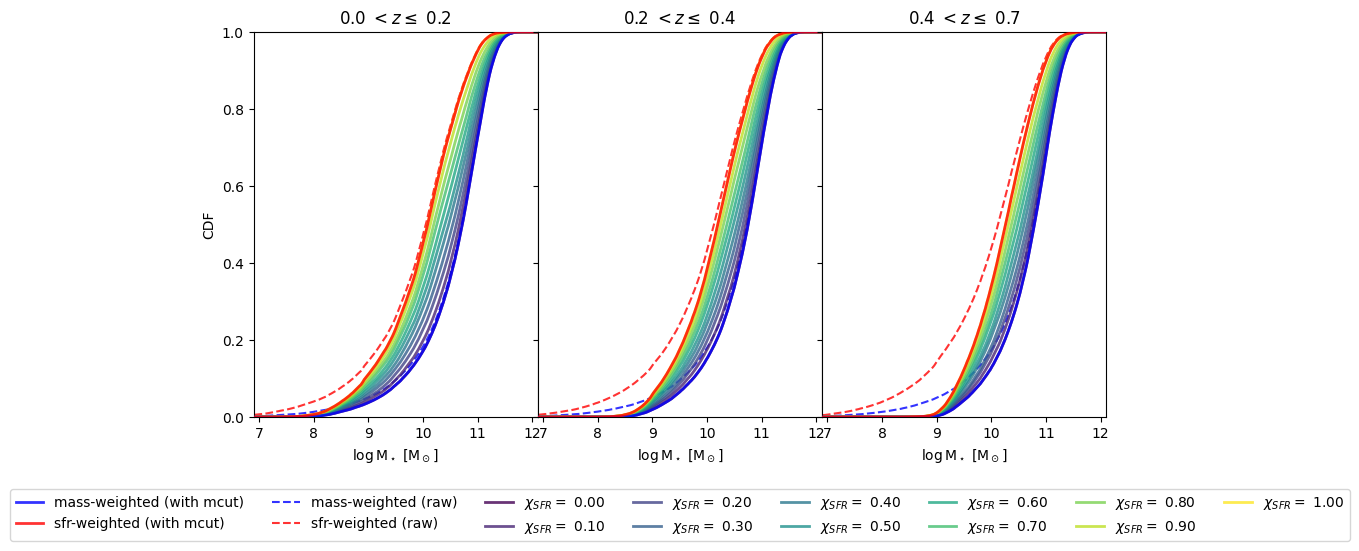

In [29]:
test_stored_data()

---

Call the `cdfmass_mixed_population_with_mcut` function:

        cdfmass_mixed_population_with_mcut(zbins_index = ..., chi = ...)

It returns an ndarray of length `len(massedges) - 1`, corresponding to the CDF values within each (massedges[i], massedges[i+1]) bin 

**A simple setup to get you started with your analysis**

Assume I have $N$ FRB host galaxies at $z<0.2$ with measured stellar masses $\log M_{i}$. I find that all galaxies have $\log M > \log M_{min}$ and want to ask the following question:

> Given a chosen $\chi_{SFR}$ value of a mixed population, how many "sigmas" away is the null measurement of galaxies below $\log M_{min}$? In other words, how unlikely is the null measurement given a mixed population model?

**Answer**
> Suppose the galaxy occurences $k$ below $\log M_{min}$ follows Poisson statistics. The expectation value $\lambda$ is given from the value of the CDF at $\log M_{min}$ times the number of host galaxies $N$, i.e., 

$$\lambda = CDF(\log M_{min}, z<0.2 ~| ~\chi_{SFR}) \times N$$

The probability of a null detection is simply given by
$$p = \dfrac{\lambda^k e^{-\lambda}}{k!} \rightarrow p = e^{- CDF(\log M_{min}, z<0.2 ~| ~\chi_{SFR}) \times N}$$
where we set $k=0$.

To convert this p-value into a Gaussian “number of sigmas”, we can treat it as a one-sided significance, that is

$$\Delta ~[\sigma] = \Phi^{-1} ( 1 - p) ~[\sigma]$$

In [42]:
def produce_constraints_on_cdfmass_mixed_population_with_mcut(
        Npop: int = 20, # number of galaxies in the population
        logM_min: float = 9.2, # minimum logM_star of detected galaxies
        zbins_index: int = 0, # index of the redshift bin in which galaxies are located
        k_obs: int = 0, # number of detected galaxies below logM_min
        ):
    """ Produces constraints on the CDF mass distribution for a mixed population
    of mass-weighted and SFR-weighted galaxies, with a magnitude cut.
    """

    chi_sfr_vals = np.linspace(0,1,301)
    masscenters = (massedges[1:] + massedges[:-1])/2.  # logmass bin centers

    computed_pvalues = []
    computed_significances = []
    computed_expectation_vals = []

     # Loop over chi_sfr values
    for chi_sfr in chi_sfr_vals:
        cdfmass = cdfmass_mixed_population_with_mcut(zbins_index, chi_sfr)
        cdf_at_logM_min = np.interp(logM_min, masscenters, cdfmass) # CDF value at logM_min (through interpolation for accuracy)

        # Expected number of galaxies below logM_min
        expectation_val = Npop * cdf_at_logM_min  #i.e., lambda parameter of Poisson distribution
        computed_expectation_vals.append(expectation_val)

        # Compute p-value for observing k_obs or fewer galaxies below logM_min
        p_value = poisson.pmf(k_obs, expectation_val)
        computed_pvalues.append(p_value)

        # Convert p-value to significance (in sigma)
        significance = norm.isf(p_value)
        computed_significances.append(significance)

        print(f"chi_sfr: {chi_sfr:.2f}, CDF(logM_min): {cdf_at_logM_min:.4f}, Expectation: {expectation_val:.4f}, p-value: {p_value:.4e}, Significance: {significance:.4f} sigma")
    # Convert lists to numpy arrays for easier handling
    computed_pvalues = np.array(computed_pvalues); computed_significances = np.array(computed_significances); computed_expectation_vals = np.array(computed_expectation_vals)

    # Plot results
    fig, axs = plt.subplots(1,2 ,figsize=(12,5))
    axs[0].plot(chi_sfr_vals, computed_pvalues, color='blue', lw=2, ls='-', marker='', label='p-value')
    axs[0].set_xlabel(r'$\chi_{SFR}$', fontsize=14)
    axs[0].set_ylabel('p-value', color='blue', fontsize=14)
    axs[0].set_yscale('log')
    axs[0].tick_params(axis='y', labelcolor='blue')
    axs[0].axhline(0.05, color='blue', ls='--', lw=1)
    axs[0].axhline(0.01, color='blue', ls=':', lw=1)
    axs[0].set_title(f'Constraining power for (Npop={Npop}, k_obs={k_obs}, logM_min={logM_min})', fontsize=16)
    ax2 = axs[0].twinx()
    ax2.plot(chi_sfr_vals, computed_significances, color='red', lw=2, ls='-', marker='', label='Significance')
    ax2.set_ylabel('Significance (sigma)', color='red', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='red')

    axs[1].plot(chi_sfr_vals, computed_expectation_vals, color='green', lw=2, ls='-', marker='', label='Expectation Value')
    axs[1].set_xlabel(r'$\chi_{SFR}$', fontsize=14)
    axs[1].set_ylabel('Expected Number of Galaxies below logM_min', fontsize=14)
    axs[1].set_title('Expected Number of Galaxies below logM_min', fontsize=16)
    


    plt.tight_layout()
    plt.show()



        

**Constraining power in Loudas et al. (2025)**

chi_sfr: 0.00, CDF(logM_min): 0.0516, Expectation: 1.0330, p-value: 3.5594e-01, Significance: 0.3693 sigma
chi_sfr: 0.00, CDF(logM_min): 0.0520, Expectation: 1.0393, p-value: 3.5369e-01, Significance: 0.3754 sigma
chi_sfr: 0.01, CDF(logM_min): 0.0523, Expectation: 1.0457, p-value: 3.5144e-01, Significance: 0.3814 sigma
chi_sfr: 0.01, CDF(logM_min): 0.0526, Expectation: 1.0521, p-value: 3.4921e-01, Significance: 0.3874 sigma
chi_sfr: 0.01, CDF(logM_min): 0.0529, Expectation: 1.0582, p-value: 3.4709e-01, Significance: 0.3932 sigma
chi_sfr: 0.02, CDF(logM_min): 0.0532, Expectation: 1.0643, p-value: 3.4497e-01, Significance: 0.3989 sigma
chi_sfr: 0.02, CDF(logM_min): 0.0535, Expectation: 1.0704, p-value: 3.4287e-01, Significance: 0.4046 sigma
chi_sfr: 0.02, CDF(logM_min): 0.0540, Expectation: 1.0796, p-value: 3.3973e-01, Significance: 0.4132 sigma
chi_sfr: 0.03, CDF(logM_min): 0.0544, Expectation: 1.0888, p-value: 3.3661e-01, Significance: 0.4217 sigma
chi_sfr: 0.03, CDF(logM_min): 0.0549,

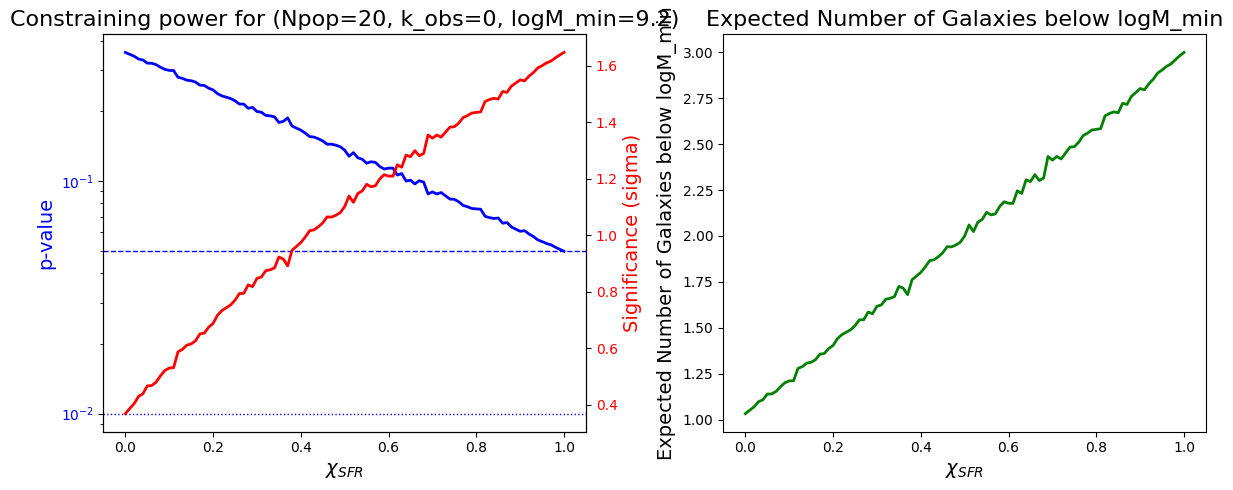

In [45]:
produce_constraints_on_cdfmass_mixed_population_with_mcut(Npop=20, logM_min=9.2, zbins_index=0, k_obs=0)

**Constraining power if we add a dozen of low-redshift galaxies, i.e., $N=20 \rightarrow N=32$**

chi_sfr: 0.00, CDF(logM_min): 0.0516, Expectation: 1.6528, p-value: 1.9152e-01, Significance: 0.8723 sigma
chi_sfr: 0.02, CDF(logM_min): 0.0535, Expectation: 1.7126, p-value: 1.8039e-01, Significance: 0.9139 sigma
chi_sfr: 0.04, CDF(logM_min): 0.0554, Expectation: 1.7734, p-value: 1.6976e-01, Significance: 0.9551 sigma
chi_sfr: 0.06, CDF(logM_min): 0.0570, Expectation: 1.8250, p-value: 1.6122e-01, Significance: 0.9894 sigma
chi_sfr: 0.08, CDF(logM_min): 0.0590, Expectation: 1.8869, p-value: 1.5154e-01, Significance: 1.0299 sigma
chi_sfr: 0.10, CDF(logM_min): 0.0606, Expectation: 1.9378, p-value: 1.4402e-01, Significance: 1.0624 sigma
chi_sfr: 0.12, CDF(logM_min): 0.0640, Expectation: 2.0464, p-value: 1.2920e-01, Significance: 1.1302 sigma
chi_sfr: 0.14, CDF(logM_min): 0.0654, Expectation: 2.0924, p-value: 1.2339e-01, Significance: 1.1582 sigma
chi_sfr: 0.16, CDF(logM_min): 0.0663, Expectation: 2.1228, p-value: 1.1970e-01, Significance: 1.1765 sigma
chi_sfr: 0.18, CDF(logM_min): 0.0680,

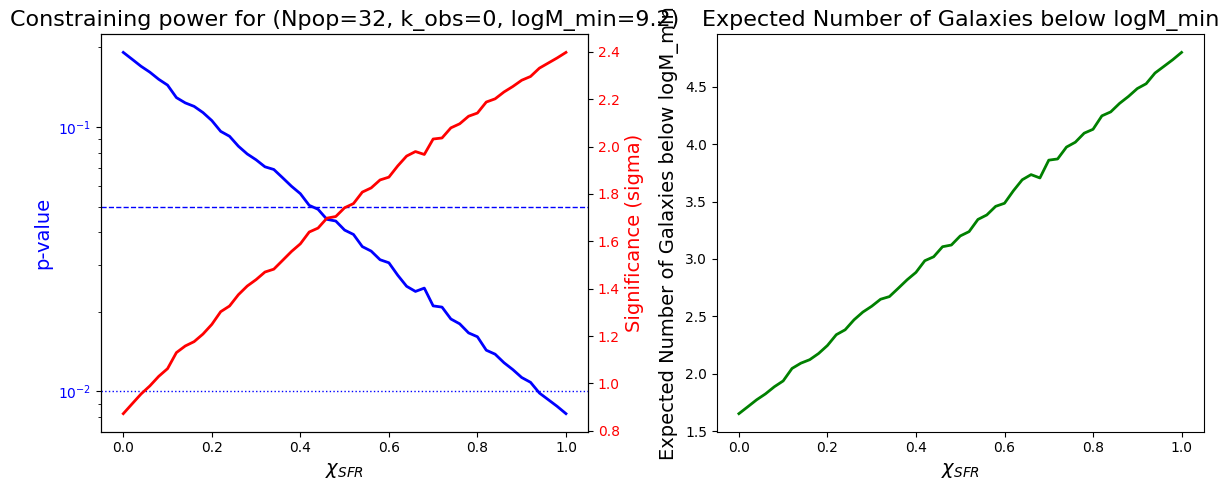

In [32]:
produce_constraints_on_cdfmass_mixed_population_with_mcut(Npop=32, logM_min=9.2, zbins_index=0, k_obs=0)

>Clearly, if the null detection of low-mass galaxies persists after adding a dozen of galaxies, we could rule out the single population scenario (FRBs-as-SFR-tracers) with $2.4 \sigma$ significance.

I hope the above example is illuminating and helps you understand how to make use of the computed CDFs. Good luck with your analysis and I'm happy to assist you further, should you find it useful. :)

In [ ]:
#EOF